In [1]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))

io$plot.dir = file.path(io$output.directory,'Plots')
dir.create(file.path(io$plot.dir), showWarnings = FALSE)
io$plot.genes = file.path(io$plot.dir,'Genes')
dir.create(file.path(io$plot.genes), showWarnings = FALSE)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [2]:
addArchRThreads(threads = 12) 

Setting default number of Parallel threads to 12.



ArchR logging to : ArchRLogs/ArchR-plotPeak2GeneHeatmap-3e7931c5785c3-Date-2022-01-11_Time-20-44-09.log
If there is an issue, please report to github with logFile!

2022-01-11 20:44:14 : Determining KNN Groups!, 0.084 mins elapsed.

Length of unique values greater than palette, interpolating..

2022-01-11 20:44:17 : Ordering Peak2Gene Links!, 0.134 mins elapsed.

2022-01-11 20:44:20 : Constructing ATAC Heatmap!, 0.184 mins elapsed.

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

2022-01-11 20:44:21 : Constructing RNA Heatmap!, 0.2 mins elapsed.

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotPeak2GeneHeatmap-3e7931c5785c3-Date-2022-01-11_Time-20-44-09.log



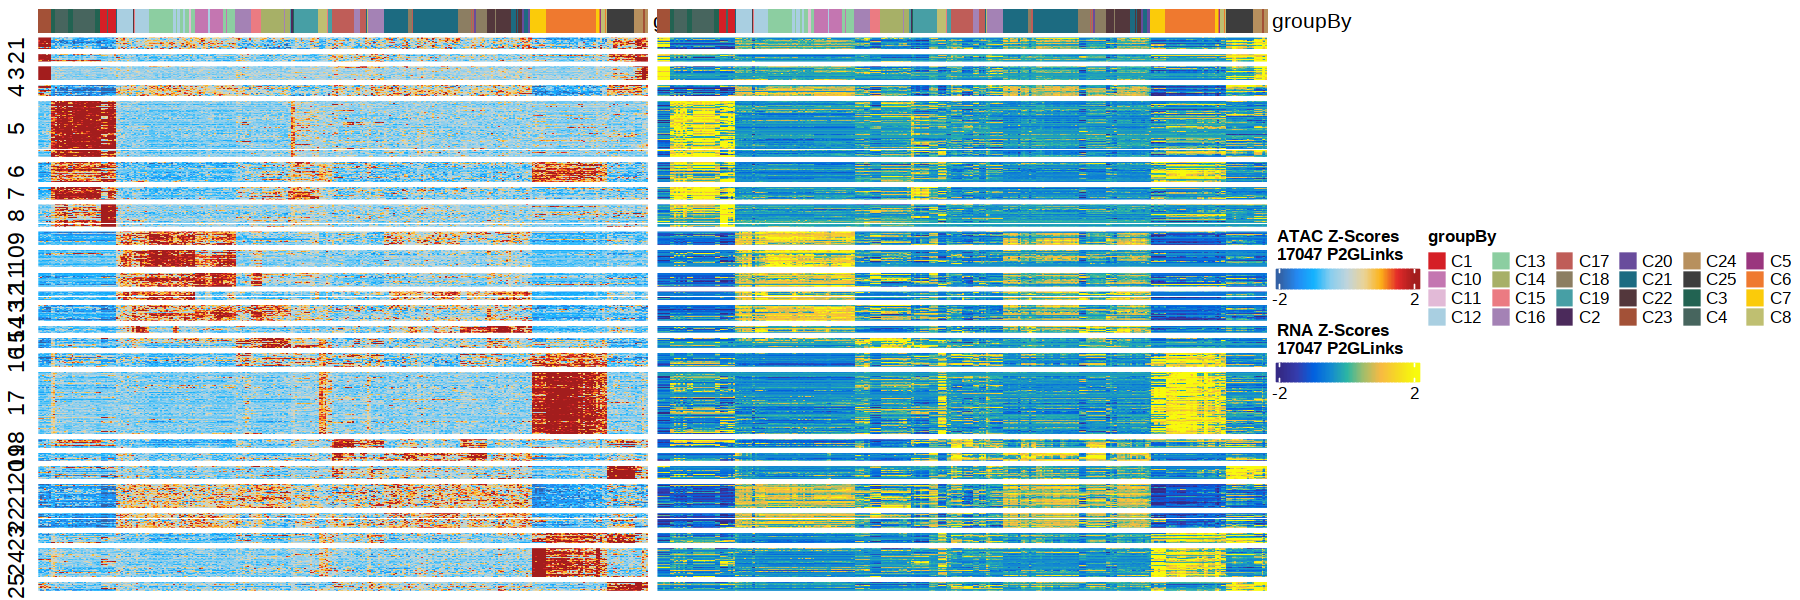

In [7]:
plotPeak2GeneHeatmap(ArchRProj = ArchRProject, groupBy = "Clusters_PeakMatrix")

# Plot genes

In [2]:
genescore_genes = getFeatures(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix")
genescore_genes = lapply(strsplit(genescore_genes, ":"), `[`, 2)

In [3]:
gene_integration_genes = getFeatures(
  ArchRProj = ArchRProject,
  useMatrix = "GeneIntegrationMatrix_PeakMatrix")
gene_integration_genes = lapply(strsplit(gene_integration_genes, ":"), `[`, 2)

In [4]:
all_genes = intersect(genescore_genes, gene_integration_genes)

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-1fac43ab484e7-Date-2022-01-18_Time-15-57-12.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneIntegrationMatrix_PeakMatrix

Getting Matrix Values...

2022-01-18 15:57:12 : 



Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-1fac43ab484e7-Date-2022-01-18_Time-15-57-12.log



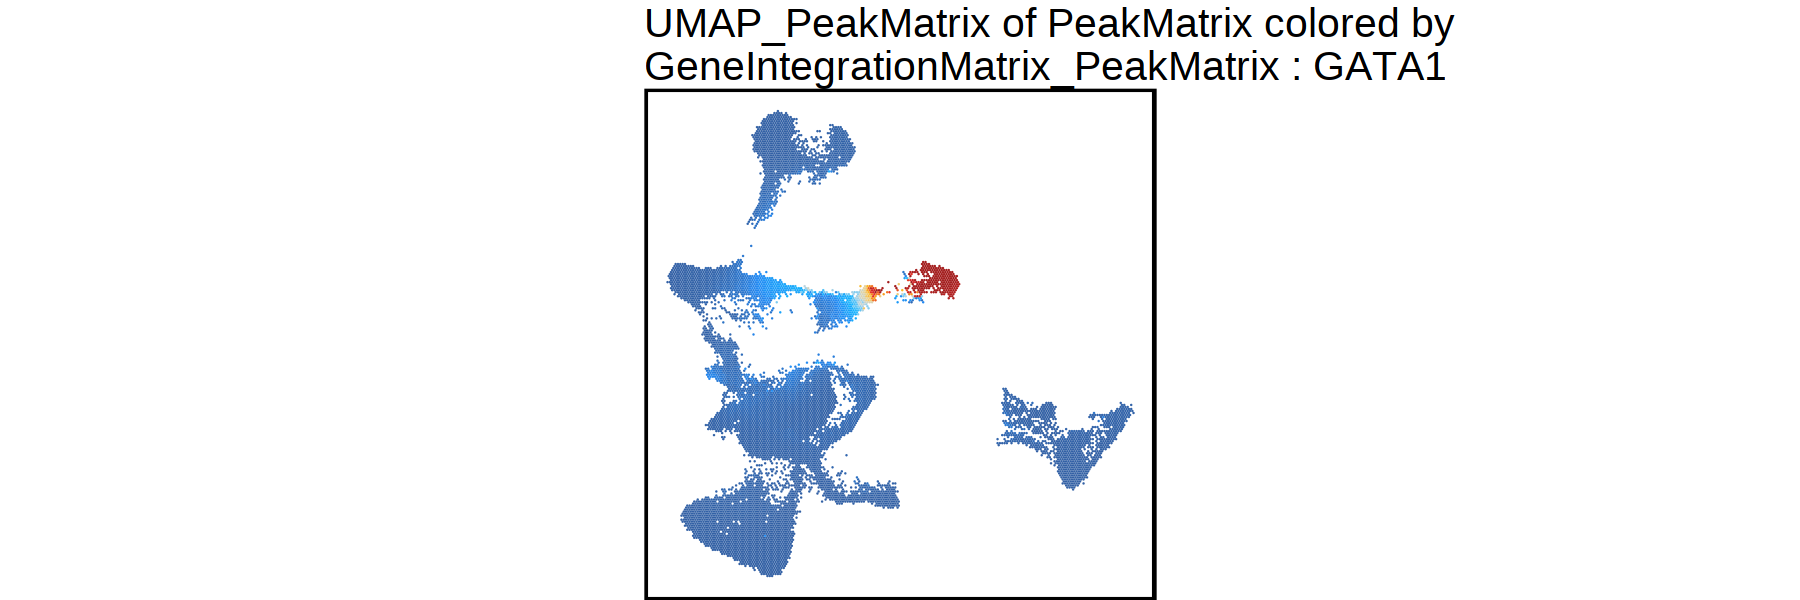

In [21]:
plotEmbedding(
        ArchRProj = ArchRProject, 
        colorBy = "GeneIntegrationMatrix_PeakMatrix", 
        name = 'GATA1', 
        embedding = "UMAP_PeakMatrix",
        imputeWeights = getImputeWeights(ArchRProject)
        ) + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20))

In [5]:
plot_gene = function(gene){
    p1 = plotEmbedding(
        ArchRProj = ArchRProject, 
        colorBy = "GeneScoreMatrix", 
        name = gene, 
        embedding = "UMAP_PeakMatrix",
        imputeWeights = getImputeWeights(ArchRProject)
        ) + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle(gene, 'Gene Accessibility')

    p2 = plotEmbedding(
        ArchRProj = ArchRProject, 
        colorBy = "GeneIntegrationMatrix_PeakMatrix", 
        name = gene, 
        embedding = "UMAP_PeakMatrix",
        imputeWeights = getImputeWeights(ArchRProject)
        ) + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle('', 'Pseudo-Expression') 

    markerMotifs <- grep("z:", getFeatures(ArchRProject, select = gene, useMatrix = "MotifMatrix"), value = TRUE)
    if(length(markerMotifs>0)){
       p3 = plotEmbedding(
        ArchRProj = ArchRProject, 
        colorBy = "MotifMatrix", 
        name = markerMotifs[1], 
        embedding = "UMAP_PeakMatrix",
        imputeWeights = getImputeWeights(ArchRProject)
        ) + 
        scale_fill_viridis() + 
        theme_void() + 
        theme(legend.position='none',
              panel.border = element_rect(fill=NA, size = 1.5),
              text = element_text(size = 20)) +  
        ggtitle('', 'Motif Accessibility')
    }
        
 
    p4 = plotBrowserTrack(
        ArchRProj = ArchRProject, 
        groupBy = "Clusters_PeakMatrix", 
        geneSymbol = gene, 
        upstream = 20000,
        downstream = 20000,
        useMatrix = 'GeneIntegrationMatrix_TileMatrix',
        #useMatrix = 'GeneScoreMatrix', # For Gata1 this didn't look good, don't know why
        loops = getPeak2GeneLinks(ArchRProject, resolution = 100)
       # loops = getCoAccessibility(ArchRProject.filt, resolution = 10000)
    ) 

    if(length(markerMotifs>0)){
      umaps = ggarrange(p1, p2, p3, ncol = 3)
    }  else{umaps = ggarrange(p1, p2, ncol = 2)}
    track = ggarrange(p4[[1]])
   p = ggarrange(umaps, track, ncol=1, heights = c(5, 10))
   p
   
    outfile <- sprintf("%s/%s.pdf",io$plot.genes, gene)
    pdf(outfile, width=10, height=10)
        print(p)
    dev.off()
   
}

In [6]:
#     'ENSOCUG00000017835', # DNMT3B > epiblast
#     'ENSOCUG00000025597', # GATA1 -> blood
#     'ENSOCUG00000009246', # GCM1 --> SCT 
#     'ENSOCUG00000026343', # VTCN1 --> amniotic ectoderm
#     'ENSOCUG00000000041', # NKX2-5 > heart
#     'ENSOCUG00000010829', # MYL4 > cardiomyocytes
#     'ENSOCUG00000015170', # HOXA11 > Allantois
#     'ENSOCUG00000017248', # TAL1
#     'ENSOCUG00000000451', # EOMES
#     'ENSOCUG00000002633', # OTX2 > neural
#     'ENSOCUG00000004752', # SIX6 > neural
#     'ENSOCUG00000014268', # Six1 > neural
#     'ENSOCUG00000005360', # Noto > Notochord
#     'ENSOCUG00000007084', # CHR > notochord
#     'ENSOCUG00000011487', # DKK1 > Gut/AVE
#     'ENSOCUG00000010192' # CDH5 > endothelium

genes = c(#'GATA1','DNMT3B','GCM1','VTCN1',
         # 'MYL4','HOXA11','TAL1','EOMES','OTX2','SIX6', 
         # 'NOTO', 'CHR', 'DKK1', 'CDH5',
        #'ELF5','CDK2', 'CDX4', 'ID1', 'ID2', 'SYN1', 'TEAD1', 'TFAP2B', 'VTCN1',
#         'GATA2', 'GATA3', 'ETV', 'RUNX1', 'LAMB1', 'TFAP2C', 'APOA2', 
#         'TTR', 'EMB',  'AMOT', 'KRT19', 'KRT8', 'KRT18','PAX6', 'PAX2', 'PECAM1', 'ANXA5', 
#         'TFAP2A', 'PAX3', 'FOXD3', 'HESX1', 'LMO2', 'KDR', 'TNNT2', 'HOXA11', 'ACTA2', 'DLL1', 'ETV2',
#         'MEOX1', 'TBX1', 'CDX2', 'MESP2', 'T', 'CER1', 'APELA', 'FOXA2', 'GSC', 'MIXL1', 'OTX2', 
#         'DPPA3', 'NANOG', 'UTF1', 'EPCAM', 'POU5F1'
        'ORY1')


In [7]:
genes = genes[genes %in% all_genes]
genes

[1] "ORY1"

character(0)

In [24]:
ArchRProject@geneAnnotation$genes[ArchRProject@geneAnnotation$genes$gene_id=='ENSOCUG00000029640']

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id             symbol
         <Rle>         <IRanges>  <Rle> |        <character>        <character>
  [1]    chr12 99949134-99950867      + | ENSOCUG00000029640 ENSOCUG00000029640
  -------
  seqinfo: 22 sequences from an unspecified genome

In [22]:
length(all_genes)

[1] 19478

In [9]:
run_plot_gene = function(gene){suppressMessages(plot_gene(gene))}
sapply(genes, run_plot_gene)

named list()

In [25]:
genes = 'ENSOCUG00000029640'
sapply(genes, run_plot_gene)

GRanges object with 1 range and 2 metadata columns:
      seqnames            ranges strand |            gene_id             symbol
         <Rle>         <IRanges>  <Rle> |        <character>        <character>
  [1]    chr12 99949134-99950867      + | ENSOCUG00000029640 ENSOCUG00000029640
  -------
  seqinfo: 22 sequences from an unspecified genome


Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead.”
Warning message:
“Removed 33 rows containing missing values (position_stack).”
Warning message:
“Removed 1 rows containing missing values (geom_segment).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”


ENSOCUG00000029640.png 
                     2

In [11]:
ArchRProject


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(42): stage_clusters.3 sample ... cell.4
  celltype_manual_refined
numberOfCells(1): 50525
medianTSS(1): 3.353
medianFrags(1): 34982

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-10d48481330b6-Date-2022-01-12_Time-15-09-02.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneIntegrationMatrix_TileMatrix

Getting Matrix Values...

2022-01-12 15:09:02 : 



Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-10d48481330b6-Date-2022-01-12_Time-15-09-02.log

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-10d4845902f83-Date-2022-01-12_Time-15-09-11.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneIntegrationMatrix_PeakMatrix

Getting Matrix Values...

2022-01-12 15:09:12 : 



Imputing Matrix

Using weights on disk

Using weights on disk

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-10d4845902f83-Date-2022-01-12_Time-15-09-11.log



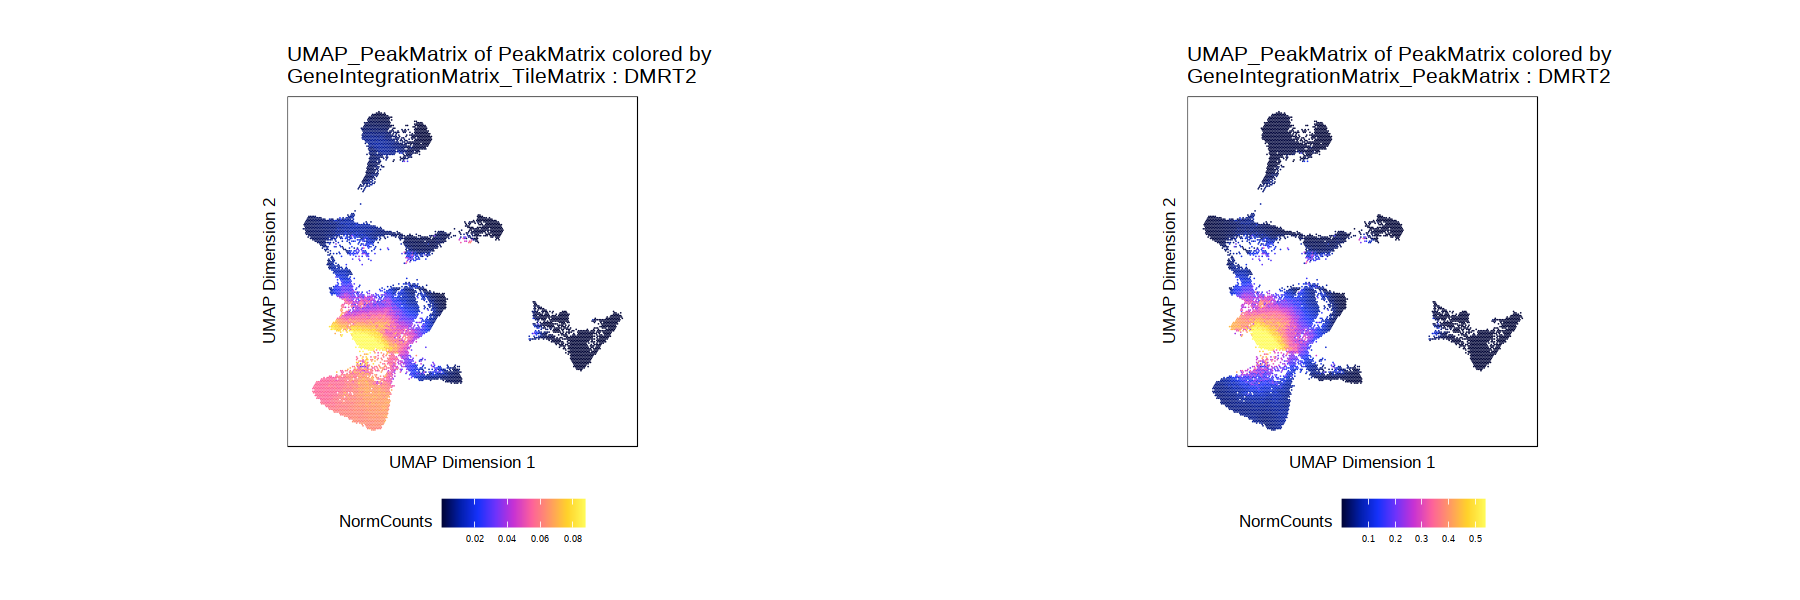

In [27]:
markerGenes = c('DMRT2')

p1 <- plotEmbedding(
    ArchRProj = ArchRProject, 
    colorBy = "GeneIntegrationMatrix_TileMatrix", 
    name = markerGenes, 
    continuousSet = "horizonExtra",
    embedding = "UMAP_PeakMatrix"
) 

p2 <- plotEmbedding(
    ArchRProj = ArchRProject, 
    colorBy = "GeneIntegrationMatrix_PeakMatrix", 
    continuousSet = "horizonExtra",
    name = markerGenes, 
    embedding = "UMAP_PeakMatrix"
)

cowplot::plot_grid(p1, p2)